<h1 align = "center">Detected Exoplanets</h1>

| Rank | Name | Input Catalog | Orbital Period | Exoplanet Radius | Orbital Distance | Habitable Zone? |
| :- | :- | :- | -: | -: |-: | -: |
|Max Radius| BD-14 3065 b | TIC 293607057 | 4.29 d| 20.44 R⊕| 0.058 AU | too hot|
|Min Radius| L 98-59 b | TIC 307210830 | 2.25 d| 0.91 R⊕| 0.022 AU  |  too hot |
|Max Period| TOI-1836 b | TIC 207468071 | 20.38 d| 8.96 R⊕| 0.158 AU | too hot |
|Min Period| L 98-59 b | TIC 307210830 | 2.25 d| 0.91 R⊕| 0.022 AU  |  too hot |
|Max Exoplanets| TOI-270 b | TIC 259377017 | 3.36 d| 1.25 R⊕| 0.031 AU  |  too hot |
|Max Exoplanets| TOI-270 c | TIC 259377017 | 5.66 d| 2.34 R⊕| 0.044 AU | too hot |
|Max Exoplanets| TOI-270 d | TIC 259377017 | 11.38 d| 1.94 R⊕| 0.071 AU | too hot |

<div align = "center">gas giant > 6 R⊕ > neptunian > 4 R⊕ > sub-neptune > 2 R⊕ > super-earth > 1.5 R⊕ > terrestrial</div>

In [1]:
%matplotlib widget
import statistics
import matplotlib.pyplot as plt
import lightkurve as lk
import numpy as np
from scipy import stats
from scipy.optimize import least_squares
from astropy import units as u
from astropy import constants as const
from astroquery.mast import Catalogs
import batman

In [2]:
render_plots = True

In [3]:
input_catalog = input('input catalog: ')
split = input_catalog.split(' ')
telescope = split[0]

if telescope == 'TIC':
    author = 'SPOC'
if telescope == 'KIC':
    author = 'Kepler'

try:
    star = Catalogs.query_object(input_catalog, catalog = 'TIC')
except:
    print('MAST import error: try again')

input catalog:  TIC 307210830


In [4]:
automate_data_cell = True

In [5]:
def import_tess(input_catalog, author, all_data, years):    
    sectors_list = []
    for sector in all_data.table:
        sectors_list.append(int(sector['sequence_number']))

    if years == 0:
        yr_range, year_mask = limit_range(all_data)
        if yr_range > 5:           
            selected_data = all_data[year_mask]
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list)[year_mask].download_all()
        else:
            selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', limit = 5)
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list).download_all()
    else:
        year_mask = (all_data.table['year'] >= years[0]) & (all_data.table['year'] <= years[-1])
        selected_data = all_data[year_mask]
        raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list)[year_mask].download_all()
        
    print('\nselected data:')
    print(selected_data)        
    return raw_ts, sectors_list, selected_data

def import_kepler(input_catalog, author, all_data, years):    
    quarters_list = []
    for quarter in all_data.table:
        quarters_list.append(int(quarter['mission'].split(' ')[2]))

    if years == 0:
        yr_range, year_mask = limit_range(all_data)
        if yr_range > 5:            
            selected_data = all_data[year_mask]
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list)[year_mask].download_all()
        else:
            selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', limit = 5)
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list).download_all()
    else:
        year_mask = (all_data.table['year'] >= years[0]) & (all_data.table['year'] <= years[-1])
        selected_data = all_data[year_mask]
        raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list)[year_mask].download_all()

        
    print('\nselected data:')
    print(selected_data)
    return raw_ts, quarters_list, selected_data

def limit_range(all_data):
    all_years = []
    for each in all_data:
        all_years.append(each.year.item())
    yr_max_i = np.max(range(len(all_years)))
    yr_max = (all_years[yr_max_i])
    yr_min = (all_years[0])
    yr_range = yr_max - yr_min

    if yr_range > 5:
        yr_count = np.bincount(all_years)
        yr_mode = round(np.argmax(yr_count))
        yr_median = round(np.median(all_years))

        if np.max(yr_count) > 5:
            year_mask = (all_data.table['year'] >= yr_mode - 2) & (all_data.table['year'] <= yr_mode + 2)
        else:
            year_mask = (all_data.table['year'] >= yr_median - 2) & (all_data.table['year'] <= yr_median + 2)
    else:
        year_mask = all_years
    return yr_range, year_mask

all_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short')
print('all data:')
print(all_data)

if automate_data_cell == True:
    years = 0
    automate_data_cell = False
else:
    years_input = input('Year Range: ')
    years_range = years_input.split('-')
    years_min = int(years_range[0])
    years_max = int(years_range[-1])
    if years_min != years_max:
        years = [years_min]
        i = 1
        while years[-1] != years_max:
            years.append(years_min + i)
            i += 1
    
if telescope == 'TIC':
    raw_ts, sectors, selected_data = import_tess(input_catalog, author, all_data, years)
if telescope == 'KIC':
    raw_ts, quarters, selected_data = import_kepler(input_catalog, author, all_data, years)

all data:
SearchResult containing 27 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 02 2018   SPOC     120   307210830      0.0
  1 TESS Sector 05 2018   SPOC     120   307210830      0.0
  2 TESS Sector 08 2019   SPOC     120   307210830      0.0
  3 TESS Sector 09 2019   SPOC     120   307210830      0.0
  4 TESS Sector 10 2019   SPOC     120   307210830      0.0
  5 TESS Sector 11 2019   SPOC     120   307210830      0.0
  6 TESS Sector 12 2019   SPOC     120   307210830      0.0
  7 TESS Sector 28 2020   SPOC     120   307210830      0.0
  8 TESS Sector 29 2020   SPOC     120   307210830      0.0
  9 TESS Sector 32 2020   SPOC     120   307210830      0.0
 10 TESS Sector 39 2021   SPOC     120   307210830      0.0
 11 TESS Sector 37 2021   SPOC     120   307210830      0.0
 12 TESS Sector 38 2021   SPOC     120   307210

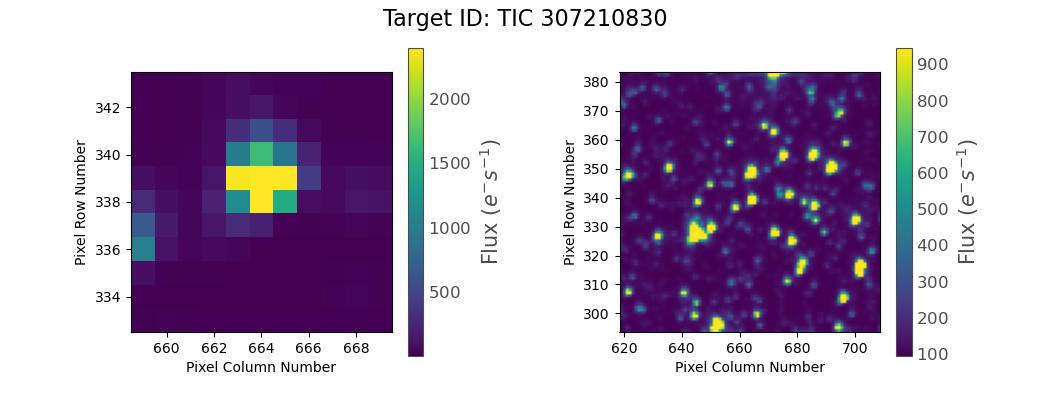

In [6]:
if render_plots == True:
    if telescope == 'TIC':
        fig, (ax1, ax2) = plt.subplots(nrows = 1 ,ncols = 2, figsize = (10.5, 4))
        fig.suptitle(f'Target ID: {input_catalog}', fontsize = 16)
        fig.subplots_adjust(wspace = .5)
        
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = 'short', sector = sectors[0]).download()
        px_file.plot(ax = ax1, title = '')
        
        ff_file = lk.search_tesscut(input_catalog, sector = sectors[0]).download(cutout_size = 90)
        ff_file.plot(ax = ax2, title = '')
        
    if telescope == 'KIC':
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = 'short', quarter = quarters[0]).download()
        px_file.plot()
        plt.title(f'Target ID: {input_catalog}', fontsize = 16)

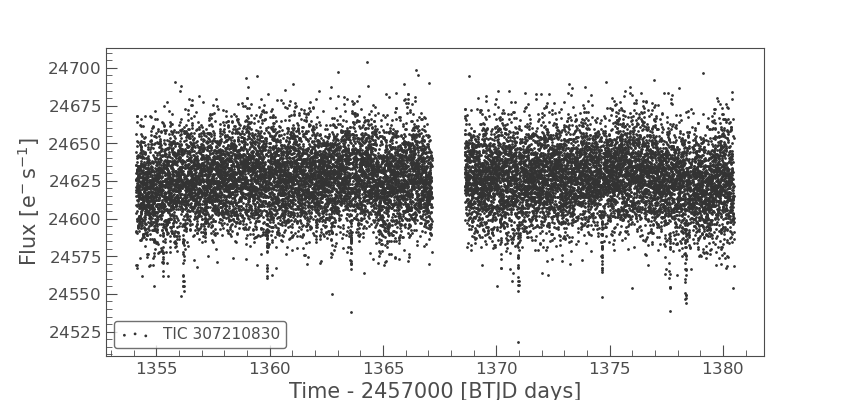

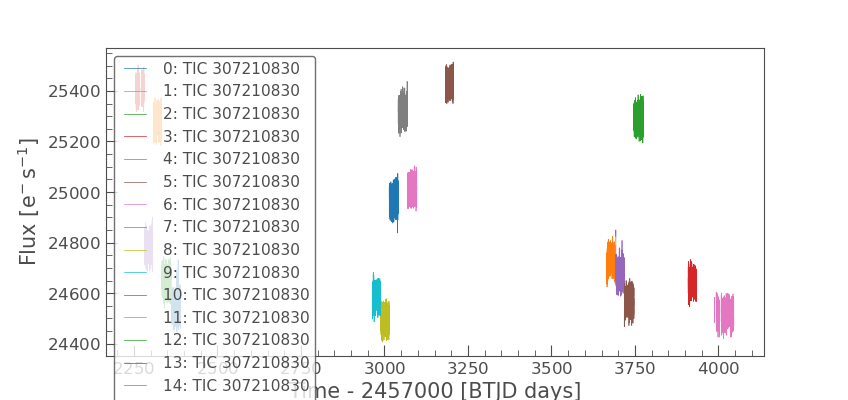

In [7]:
if telescope == 'TIC':
    first_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors[0], limit = 1).download()
    if len(sectors) > 1:
        refined_ts = raw_ts.stitch().remove_nans().flatten()
    else:
        first_ts.scatter()
        refined_ts = first_ts.remove_nans().flatten()

if telescope == 'KIC':
    first_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters[0], limit = 1).download()
    if len(quarters) > 1:
        refined_ts = raw_ts.stitch().remove_nans().flatten()
    else:
        first_ts.scatter()
        refined_ts = first_ts.remove_nans().flatten()

if render_plots == True:
    first_ts.scatter()
    raw_ts.plot()

In [8]:
bin_count = 100000
if len(refined_ts) > bin_count:
    bin_width = (np.max(refined_ts.time.value)-np.min(refined_ts.time.value))/(bin_count/.94)
    harmonics_ts = refined_ts.bin(bin_width) 
else:
    harmonics_ts = refined_ts
print(f'Number of folded points in harmonics test: {len(harmonics_ts)}')

Number of folded points in harmonics test: 100089


In [9]:
add_period = False

`period` contains 117766 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.
`period` contains 138475 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.
`period` contains 316110 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.
`period` contains 421608 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.
`period` contains 1468642 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


Period: 3.6907 d (SNR: 58.905)
Period: 7.4507 d (SNR: 32.2123)
Period: 2.2531 d (SNR: 21.9799)


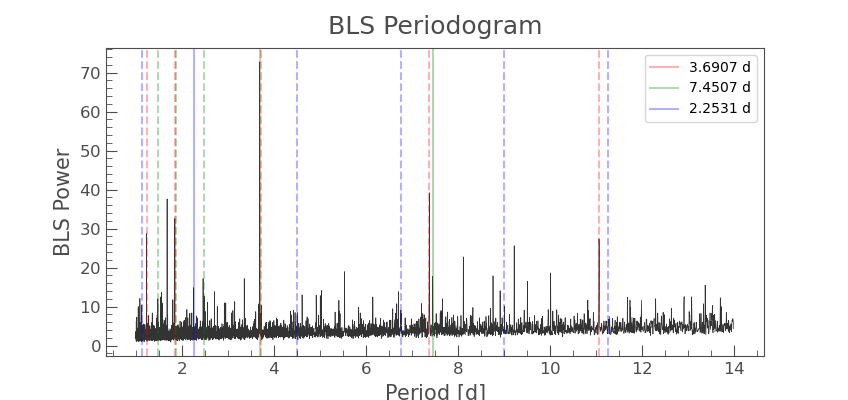

In [10]:
def initial_bls(ts, min_period, max_period):
    search_duration = np.linspace(.05, .3, 10)
    search_period = np.logspace(np.log10(min_period), np.log10(max_period), 5000) 
    initial_periodogram = ts.to_periodogram(method = 'bls', period = search_period, duration = search_duration, frequency_factor = 1000)
    initial_period = initial_periodogram.period_at_max_power
    initial_duration = initial_periodogram.duration_at_max_power  
    return initial_periodogram, initial_period, initial_duration
    
def refine_bls(ts, prev_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(prev_period.value - .1, prev_period.value + .1, 5000)
    refined_periodogram = ts.to_periodogram(method = 'bls', period = period, duration = duration)
    refined_period = refined_periodogram.period_at_max_power
    refined_duration = refined_periodogram.duration_at_max_power
    refined_time = refined_periodogram.transit_time_at_max_power
    refined_depth = refined_periodogram.depth_at_max_power
    return refined_periodogram, refined_period, refined_duration, refined_time, refined_depth

def search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts):
    harmonics = [refined_period.value]
    i = 2
    while i <= 5:
        harmonics_divide = refined_period.value/i
        harmonics_multiply = refined_period.value*i
        if harmonics_divide >= min_period:
            harmonics.append(harmonics_divide)
        if harmonics_multiply <= max_period:
            harmonics.append(harmonics_multiply)
        i += 1 
    harmonics.sort()
    
    dip_ratio = []
    for each in harmonics:
        folded = harmonics_ts.fold(period = each, epoch_time = refined_time)
        in_transit = np.logical_and((folded.phase.value > -refined_duration.value/3), (folded.phase.value < refined_duration.value/3))
        above_dip = folded.flux.value > 1-refined_depth*(2/3)
        both = np.logical_and(in_transit, above_dip)
        dip_ratio.append(len(folded[both])/len(folded[in_transit]))

        #lim_folded = folded[in_transit]
        #folded.scatter(title = f'index {harmonics.index(each)}: {round(each*u.day,4)}')
        #plt.axhline(1-refined_periodogram.depth_at_max_power*(2/3), color = "green")
        #plt.axvline(-refined_duration.value/3, color = "green")
        #plt.axvline(refined_duration.value/3, color = "green")
        #plt.xlim(-.1,.1)
        #plt.ylim(.9995, 1.0005)
    
    high_freq_h = []
    mean = (dip_ratio[0]+dip_ratio[-1])/2
    
    i = 0
    while i < len(dip_ratio):
        if dip_ratio[i] > mean:
            high_freq_h.append(dip_ratio[i])
        i += 1
    
    transit_index = len(high_freq_h)
    return harmonics, transit_index

def mask_ts(time_series, ts, selected_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(selected_period - .1, selected_period + .1, 5000)
    final_periodogram = ts.to_periodogram(method = 'bls', period = period, duration = duration)
    final_period = final_periodogram.period_at_max_power
    final_duration = final_periodogram.duration_at_max_power
    final_time = final_periodogram.transit_time_at_max_power
    final_depth = final_periodogram.depth_at_max_power
    
    mask = final_periodogram.get_transit_mask(period = final_period, transit_time = final_time, duration = final_duration*2)
    masked_ts = ts[~mask]
    time_series.append(masked_ts)
    return final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth

def plot_periodogram(periodogram, selected_periods, min_period, max_period):
    periodogram.plot(title = 'BLS Periodogram', label = '_nolegend_')
    
    i = 0
    while i < len(selected_periods):
        if i == 0:
            color = 'red'
        if i == 1:
            color = 'green'
        if i == 2:
            color = 'blue'
        if i == 3:
            color = 'orange'
        if i == 4:
            color = 'purple'
        plt.axvline(selected_periods[i], color = color, alpha = .3)

        labels = []
        for each in selected_periods:
            labels.append(round(each,4)*u.day)
        plt.legend(labels)
        
        x = 2
        while x <= 5:
            harmonics_divide = selected_periods[i]/x
            harmonics_multiply = selected_periods[i]*x
            if harmonics_divide >= min_period:
                plt.axvline(harmonics_divide, color = color, linestyle = '--', alpha = .3, label = '_nolegend_')
            if harmonics_multiply <= max_period:
                plt.axvline(harmonics_multiply, color = color, linestyle = '--', alpha = .3, label = '_nolegend_')
            x += 1 
        i += 1

if add_period == False:
    min_period = 1
    max_period = 14
    time_series = [refined_ts]
    cycle = 0
    selected_periods = []
    exoplanets = []
    periods = []
    durations = []
    transit_times = []
    
    while True:
        initial_periodogram, initial_period, initial_duration = initial_bls(time_series[-1], min_period, max_period)
        if cycle == 0:
            first_periodogram = initial_periodogram
        cycle += 1
    
        refined_periodogram, refined_period, refined_duration, refined_time, refined_depth = refine_bls(time_series[-1], initial_period, initial_duration)
        if np.max(refined_periodogram.snr) < 10:
            break

        harmonics, transit_index = search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts)
        for each in harmonics:
            if each == harmonics[transit_index]:
                selected_periods.append(each)
        
        final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth = mask_ts(time_series, time_series[-1], selected_periods[-1], refined_duration)
        exoplanets.append({
            'periodogram': refined_periodogram, 
            'period': final_period, 
            'duration': final_duration, 
            't0': final_time,       
            'depth': final_depth,
            'snr': np.max(final_periodogram.snr)
        }) 
        periods.append(final_period.value)
        durations.append(final_duration.value)
        transit_times.append(final_time.value)
    add_period = True
else:
    refined_periodogram, refined_period, refined_duration, refined_time, refined_depth = refine_bls(time_series[-1], initial_period, initial_duration)
    harmonics, transit_index = search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts)
    for each in harmonics:
        if each == harmonics[transit_index]:
            selected_periods.append(each)
    final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth = mask_ts(time_series, time_series[-1], selected_periods[-1], refined_duration)
    exoplanets.append({
        'periodogram': refined_periodogram, 
        'period': final_period, 
        'duration': final_duration, 
        't0': final_time,       
        'depth': final_depth,
        'snr': np.max(final_periodogram.snr)
    }) 
    periods.append(final_period.value)
    durations.append(final_duration.value)
    transit_times.append(final_time.value)  

for each in exoplanets:
    print(f'Period: {round(each["period"],4)} (SNR: {round(each["snr"],4)})')
plot_periodogram(first_periodogram, selected_periods, min_period, max_period)

In [19]:
remove_lc = False

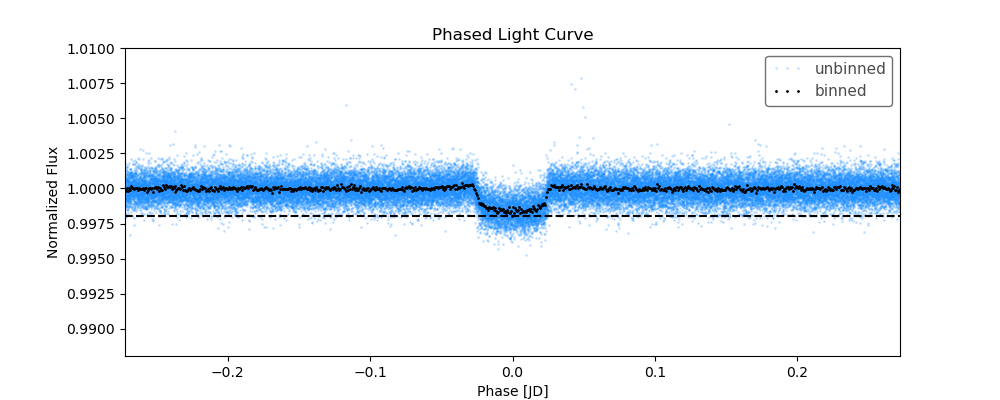

Radius:
1.5053 earthRad
0.1343 jupiterRad


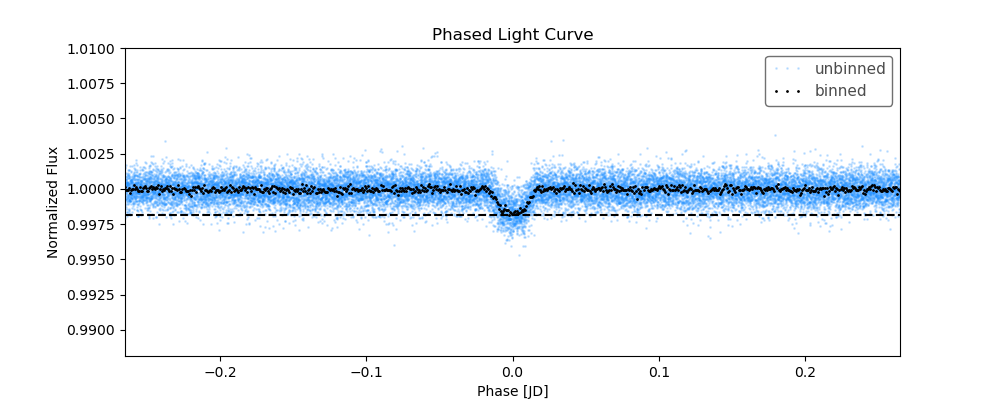

Radius:
1.4743 earthRad
0.1315 jupiterRad


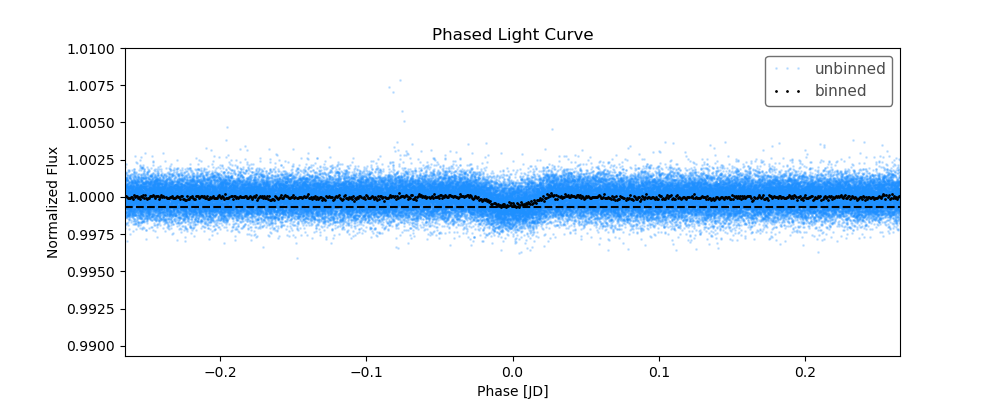

Radius:
0.8887 earthRad
0.0793 jupiterRad


In [20]:
def clean_data(mission, refined_ts):
    transit_mask = refined_ts.create_transit_mask(
                period = periods, 
                transit_time = transit_times, 
                duration = durations
            )
    if len(mission) > 1:
        clean_ts = raw_ts.stitch().remove_nans().flatten(mask = transit_mask)
    else:
        clean_ts = first_ts.remove_nans().flatten(mask = transit_mask)
    return clean_ts

def plot_light_curve(clean_ts, period, t0, duration):
    phased_lc = clean_ts.fold(period = period, epoch_time = t0)
    binned_lc = phased_lc.bin(1/60/24)
    dip = binned_lc.flux.value.min()
    depth = 1 - dip
    half_duration = duration.value/2
    if render_plots == True:
        fig, ax = plt.subplots(figsize = (10,4))
        phased_lc.plot(ax = ax, linewidth = '0', marker = ".", color = "dodgerblue", alpha = .2, label = "unbinned")
        binned_lc.plot(ax = ax, linewidth = '0', marker = ".", color = "black", label = "binned")
        plt.axhline(dip, color = 'black', linestyle = '--')
        plt.title("Phased Light Curve")
        plt.xlim(-(half_duration + .25), (half_duration + .25))
        plt.ylim(dip - .01, 1.01)
        plt.show()
    return depth, binned_lc, phased_lc

def estimate_radius(star, depth):
    exo_sun_rad = np.sqrt(depth) * (star["rad"][0] * u.R_sun)
    exo_earth_rad = exo_sun_rad.to(u.Rearth) 
    exo_jupiter_rad = exo_sun_rad.to(u.Rjupiter) 
    print('Radius:')
    print(round(exo_earth_rad, 4))
    print(round(exo_jupiter_rad, 4))
    return exo_earth_rad

def run_lc_loop(exoplanets, clean_ts):
    for each in exoplanets:
        depth, binned_lc, phased_lc = plot_light_curve(clean_ts, each["period"], each["t0"], each["duration"])
        each["depth"] = depth
    
        transit_event = np.logical_and(binned_lc.phase.value > -0.2, binned_lc.phase.value < 0.2)
        each["light_curve"] = binned_lc[transit_event]
        
        radius = estimate_radius(star, depth)
        each["radius"] = radius

if remove_lc == False:
    if telescope == "TIC":
        clean_ts = clean_data(sectors, refined_ts)
    if telescope == "KIC":
        clean_ts = clean_data(quarters, refined_ts)
        
    run_lc_loop(exoplanets, clean_ts)
    remove_lc = True
else:
    remove_index = int(input('Remove Candidate(s)?'))
    del exoplanets[remove_index]
    run_lc_loop(exoplanets, clean_ts)

In [13]:
def orbital_distance(star, period):
    star_mass = star['mass'][0]* u.M_sun
    star_mass = star_mass.to(u.kg)

    period = period.to(u.s)
    
    semimajor_axis = np.cbrt((const.G*star_mass*np.square(period))/(4*np.square(np.pi)))
    semimajor_axis = semimajor_axis.to(u.au)
    return semimajor_axis

def habitable_zone(star, semimajor_axis):
    star_luminosity = star['lum'][0]*u.L_sun

    inner_lim = np.sqrt(star_luminosity/(1.1*u.L_sun))*u.au
    outer_lim = np.sqrt(star_luminosity/(.53*u.L_sun))*u.au

    if semimajor_axis < inner_lim:
        habitability = 'too hot'
    elif semimajor_axis > outer_lim:
        habitability = 'too cold'
    else:
        habitability = 'just right'
    return habitability

for each in exoplanets:
    semimajor_axis = orbital_distance(star, each['period'])
    each['semimajor_axis'] = semimajor_axis
    print(f'semi-major axis: {round(semimajor_axis, 4)}') 
    
    habitability = habitable_zone(star, each['semimajor_axis'])
    each['habitability'] = habitability
    print(f'habitable zone: {habitability}')  

semi-major axis: 0.031 AU
habitable zone: too hot
semi-major axis: 0.0496 AU
habitable zone: too hot
semi-major axis: 0.0223 AU
habitable zone: too hot


radius: 1.2975 earthRad
inclination: 88.5954 deg
eccentricity: 0.0
argument of periapsis (w): 90.0 deg


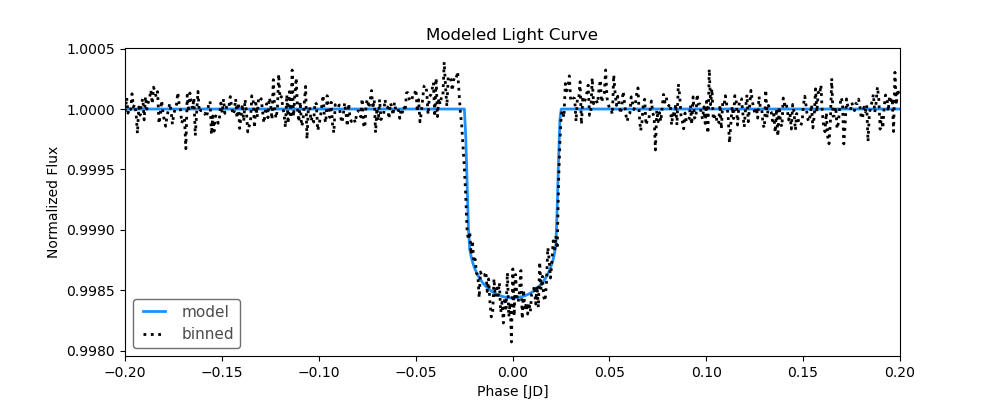

radius: 1.5069 earthRad
inclination: 88.4145 deg
eccentricity: 0.0
argument of periapsis (w): 96.5663 deg


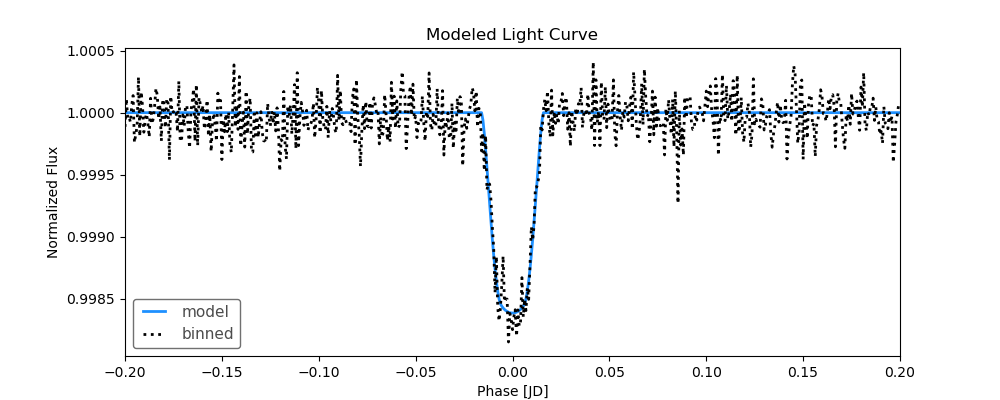

radius: 0.7491 earthRad
inclination: 87.5211 deg
eccentricity: 0.1484
argument of periapsis (w): 180.0 deg


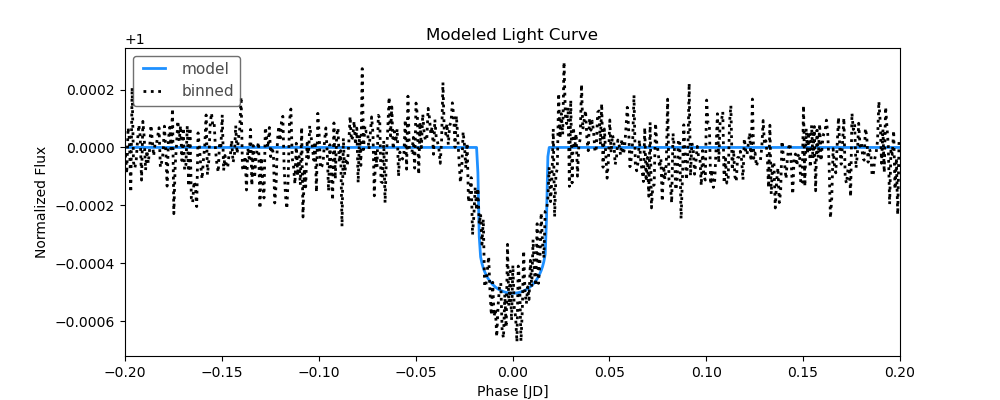

In [18]:
def initial_estimates(exoplanet, star):
    rad_est = (exoplanet['radius'].to(u.Rsun))/(star['rad'][0]*u.Rsun)
    inc_est = 90
    ecc_est = 0
    w_est = 90
    estimates = [rad_est, inc_est, ecc_est, w_est]
    lower_bounds = [rad_est-0.02,80,0,0]
    upper_bounds = [rad_est+0.02,90,0.999,180]
    return estimates, lower_bounds, upper_bounds
    
def batman_fun(x, exoplanet, star):
    params = batman.TransitParams()
    params.t0 = 0
    params.per = exoplanet['period'].value
    params.rp = x[0]
    params.a = (exoplanet['semimajor_axis'].to(u.Rsun))/(star['rad'][0]*u.Rsun)
    params.inc = x[1]
    params.ecc = x[2]
    params.w = x[3]
    params.limb_dark = 'nonlinear'
    params.u = [0.5,0.1,0.1,-0.1]  
    
    phase_min = min(exoplanet['light_curve'].phase.value)
    phase_max = max(exoplanet['light_curve'].phase.value)
    phase_len = len(exoplanet['light_curve'].flux.value)
    time = np.linspace(phase_min, phase_max, phase_len)
                       
    model = batman.TransitModel(params,time)
    batman_flux = model.light_curve(params)
    return batman_flux

def calc_residuals(x, exoplanet, star):
    observed = exoplanet['light_curve'].flux.value
    observed_error = exoplanet['light_curve'].flux_err.value
    modeled = batman_fun(x, exoplanet, star)
    
    residuals = (observed-modeled)/observed_error
    return residuals

def plot_model(each, star):
    batman_flux = batman_fun(results.x, each, star)
    phase = each['light_curve'].phase.value

    fig, ax = plt.subplots(figsize = (10,4))
    ax.plot(phase, batman_flux, linewidth = '2', color = 'dodgerblue', label = 'model')
    each['light_curve'].plot(ax = ax, linewidth = '2', linestyle = ':', color = 'black', label = 'binned')
    plt.title('Modeled Light Curve')
    plt.xlim(-0.2,0.2)
    plt.show()

for each in exoplanets:
    estimates, lower_bounds, upper_bounds = initial_estimates(each, star)
    results = least_squares(calc_residuals, estimates, bounds = (lower_bounds, upper_bounds), args = (each, star,))

    each['radius'] = (results.x[0]*star['rad'][0]*u.Rsun).to(u.Rearth)
    each['inclination'] = results.x[1]*u.degree
    each['eccentricity'] = results.x[2]
    each['arg_periapsis'] = results.x[3]*u.degree
    print(f'radius: {round(each['radius'],4)}')
    print(f'inclination: {round(each['inclination'],4)}')
    print(f'eccentricity: {round(each['eccentricity'],4)}')
    print(f'argument of periapsis (w): {round(each['arg_periapsis'],4)}')

    plot_model(each, star)

In [15]:
for each in exoplanets:
    b1 = ((each['semimajor_axis']*np.cos(each['inclination'].to(u.radian)))/((star['rad'][0]*u.Rsun).to(u.au)))
    b2 = ((1-np.square(each['eccentricity']))/(1+(np.square(each['eccentricity'])*np.sin(each['arg_periapsis'].to(u.radian)))))

    each['impact_parameter'] = b1*b2
    print(f'impact parameter: {round(each['impact_parameter'],4)}')

impact parameter: 0.5211
impact parameter: 0.9389
impact parameter: 0.6621


In [16]:
exoplanets

[{'periodogram': BoxLeastSquaresPeriodogram(ID: TIC 307210830),
  'period': <Quantity 3.69067699 d>,
  'duration': <Quantity 0.0442 d>,
  't0': <Time object: scale='tdb' format='btjd' value=2256.725904755244>,
  'depth': np.float64(0.0019295892580412088),
  'snr': <Quantity 58.90503011>,
  'light_curve': <FoldedLightCurve length=576 LABEL="TIC 307210830" SECTOR=98 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
          time                flux               flux_err        ...       pos_corr1              pos_corr2       
                                                                 ...          pix                    pix          
       TimeDelta            float64              float64         ...        float64                float64        
  -------------------- ------------------ ---------------------- ... --------------------- -----------------------
   -0.1998368802521332 0.9999775328922844 0.00010303375943555242 ...  0.008524229750037193   -0.004690302070230246
  -0.1991424358076886

#### Ideas for improvement
- test false positives
- compare results with exoplanet archive
- map on distribution trends
- create output table
- add detection for longer periods
- transit timing variations
- bin just for model, replace current binned with get_transit_model?